## Web Search Tool
Claude includes a built-in web search tool that lets it search the internet for current or specialized information to answer user questions. Unlike other tools where you need to provide the implementation, Claude handles the entire search process automatically - you just need to provide a simple schema to enable it.
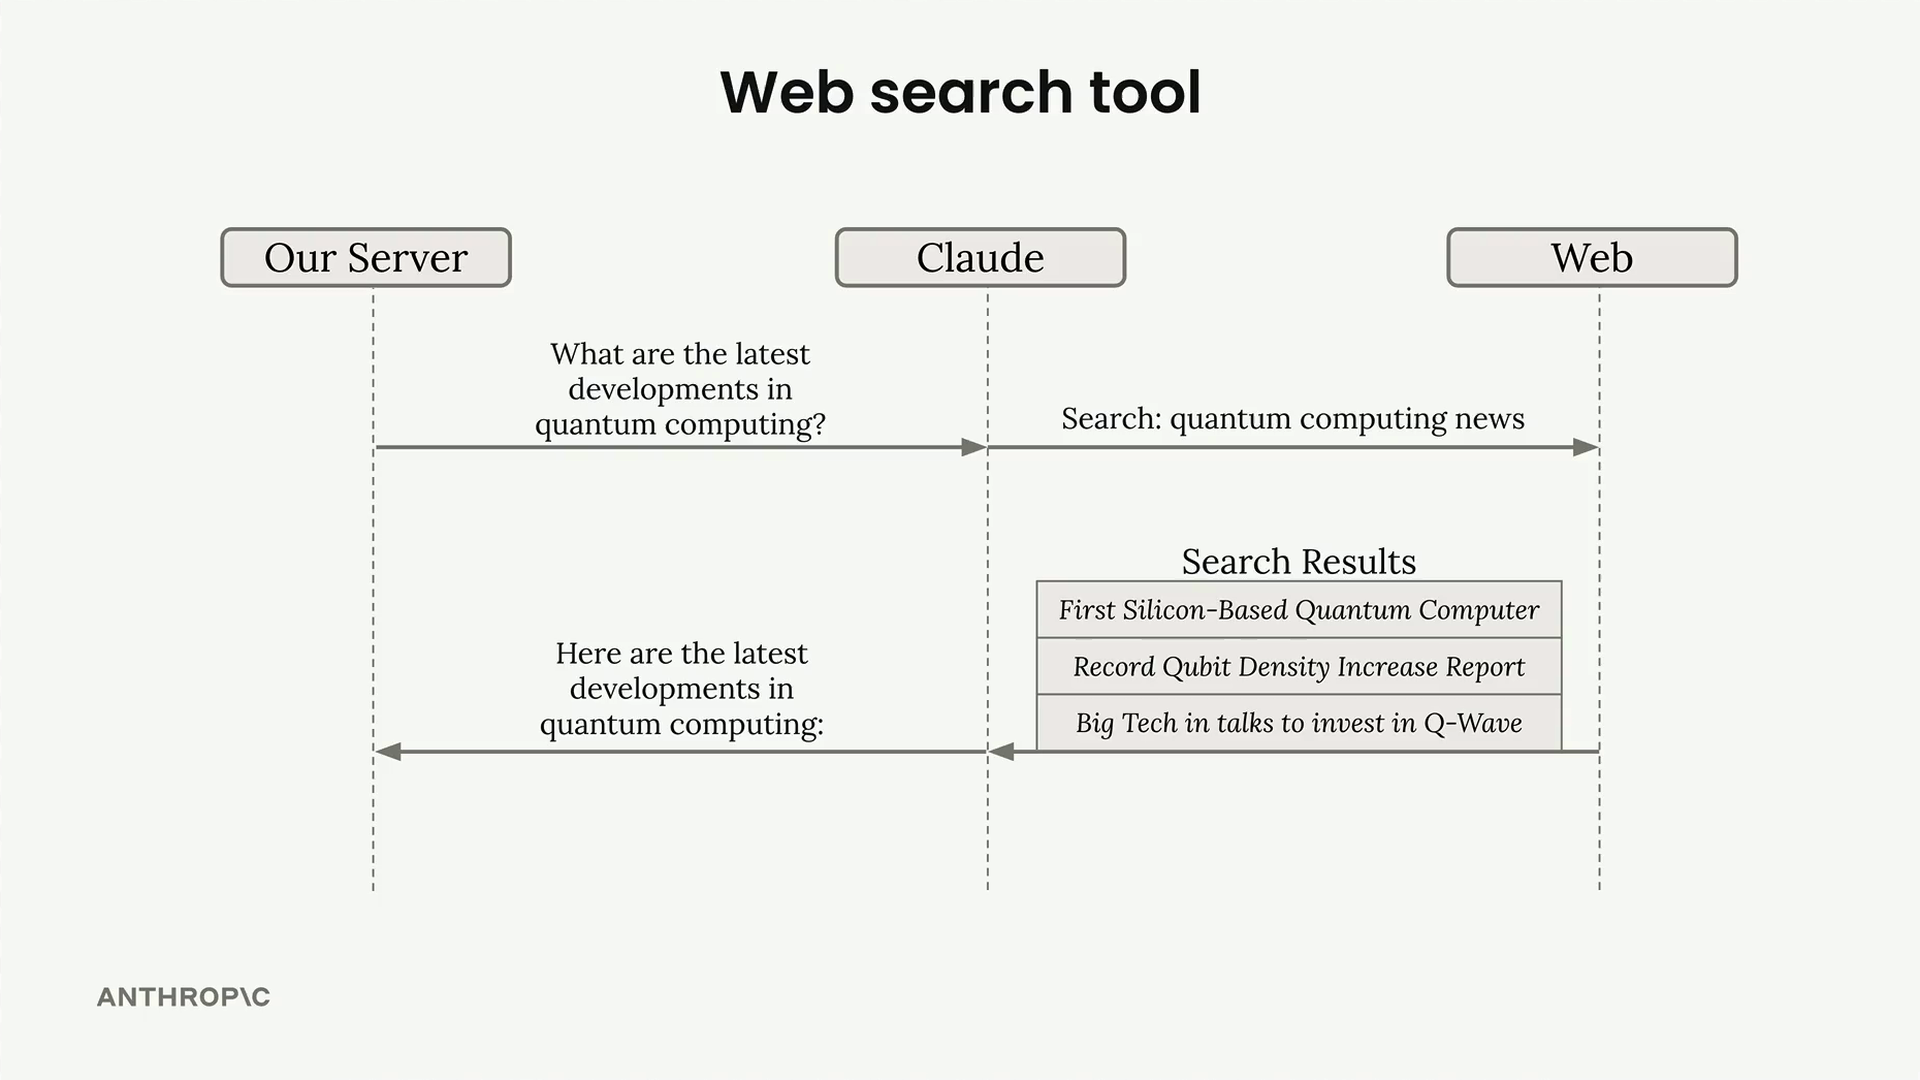

To use the web search tool, you create a schema object with these required fields:

```
web_search_schema = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 5,
    "allowed_domains": ["nih.gov"]
}
```
When Claude uses the web search tool, the response contains several types of blocks:
- Text blocks - Claude's explanation of what it's doing
- ServerToolUseBlock - Shows the exact search query Claude used
- WebSearchToolResultBlock - Contains the search results
- WebSearchResultBlock - Individual search results with titles and URLs
- Citation blocks - Text that supports Claude's statements


In [ ]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-sonnet-4-5"

In [ ]:
# Helper functions
from anthropic.types import Message


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

In [ ]:
web_search_schema = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 5,
    "allowed_domains": ["nih.gov"],
}

In [ ]:
messages = []
add_user_message(
    messages,
    """
    What's the best exercise for gaining leg muscle?
    """,
)
response = chat(messages, tools=[web_search_schema])
response